In [1]:
from scipy.special import factorial

M = 10
k = 3
p = 1/6

factorial(M) / (factorial(k) * factorial(M - k)) * p**k * (1 - p)**(M - k)

np.float64(0.15504535957425192)

In [2]:
from scipy.stats import binom

M = 10
k = 3
p = 1/6

binom.pmf(k, M, p)

np.float64(0.1550453595742519)

### Voting Classifiers

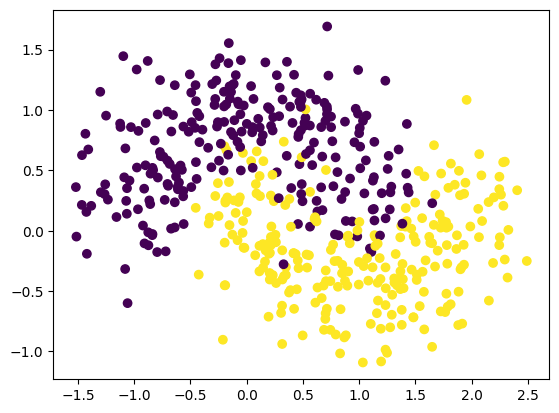

In [3]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.3, random_state=123)

import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

voting_clf = VotingClassifier([
    ('lr', LogisticRegression(random_state=123)),
    ('rf', RandomForestClassifier(random_state=123)),
    ('svc', SVC(random_state=123))
])

voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [6]:
y_pred = voting_clf.predict(X_test)
y_pred

array([1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1])

In [7]:
y_test

array([1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1])

In [8]:
voting_clf.estimators_

[LogisticRegression(random_state=123),
 RandomForestClassifier(random_state=123),
 SVC(random_state=123)]

In [9]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([1])]

In [10]:
voting_clf.named_estimators_

{'lr': LogisticRegression(random_state=123),
 'rf': RandomForestClassifier(random_state=123),
 'svc': SVC(random_state=123)}

In [11]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, '=', clf.score(X_test, y_test))

lr = 0.824
rf = 0.896
svc = 0.904


In [12]:
voting_clf.score(X_test, y_test)

0.904

In [14]:
voting_clf.voting = 'soft'
voting_clf.named_estimators_['svc'].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.912